In [1]:
import pandas as pd
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.shape


(1025, 14)

In [6]:
import plotly.express as px

fig = px.histogram(
    df,
    x="target",
    color="target",
    text_auto=True,
    labels={
        "target": "Heart Disease (0 = No, 1 = Yes)"
    },
    title="Distribution of Heart Disease Cases"
)

fig.update_layout(
    xaxis_title="Heart Disease Status",
    yaxis_title="Number of Patients",
    bargap=0.2
)

fig.show()


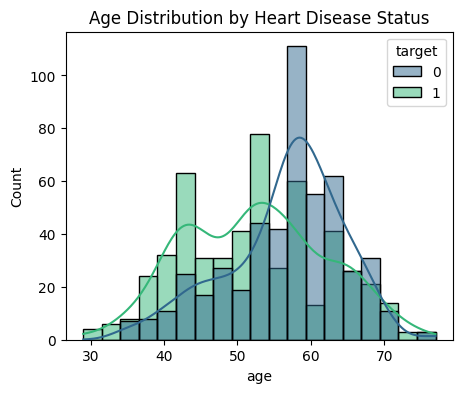

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 4))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='viridis')
plt.title('Age Distribution by Heart Disease Status')
plt.show()

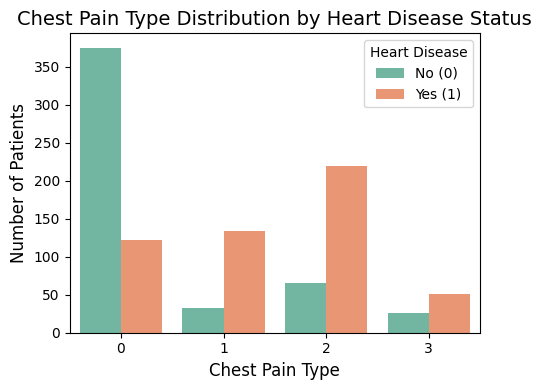

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

sns.countplot(
    x='cp',
    hue='target',
    data=df,
    palette='Set2'
)

plt.title("Chest Pain Type Distribution by Heart Disease Status", fontsize=14)
plt.xlabel("Chest Pain Type", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.legend(title="Heart Disease", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()



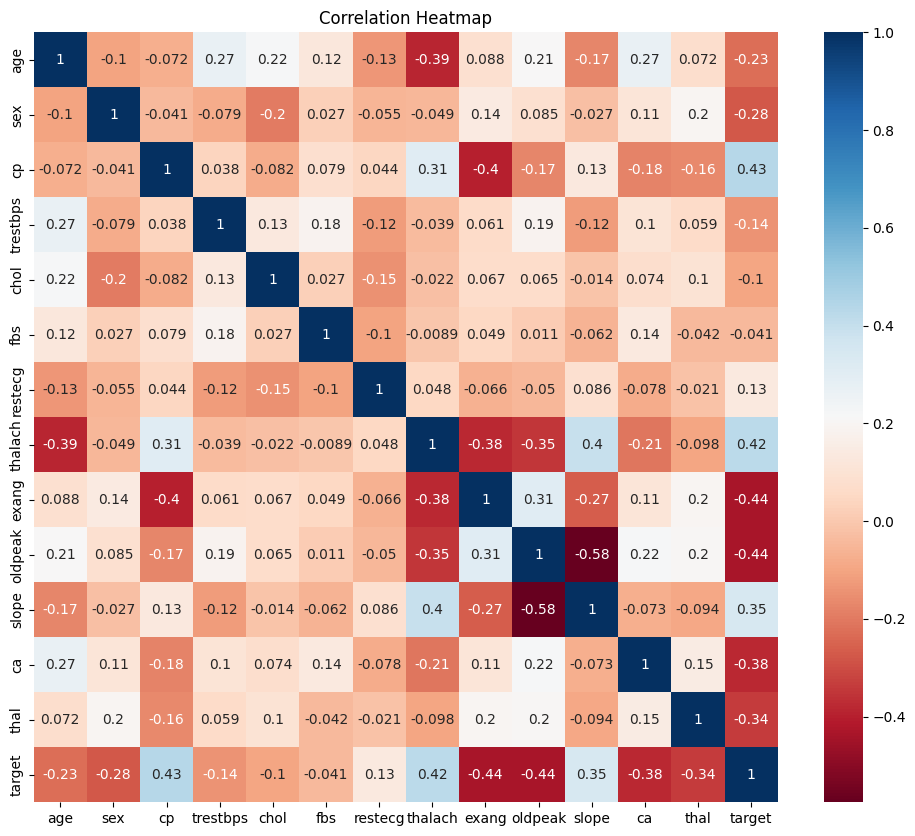

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='RdBu')
plt.title("Correlation Heatmap")
plt.show()

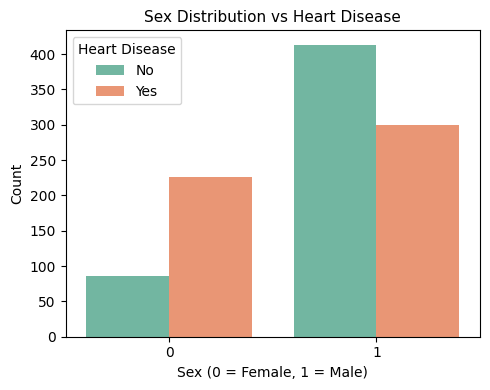

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(
    x='sex',
    hue='target',
    data=df,
    palette='Set2'
)
plt.title("Sex Distribution vs Heart Disease", fontsize=11)
plt.xlabel("Sex (0 = Female, 1 = Male)", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

In [13]:
cp_stat = pd.crosstab(df['cp'], df['target'])
cp_percentage = pd.crosstab(df['cp'], df['target'], normalize='index') * 100
display(cp_percentage.round(2))


target,0,1
cp,,
0,75.45,24.55
1,19.76,80.24
2,22.89,77.11
3,33.77,66.23


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [15]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Logistic Regression

In [18]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test, log_reg_pred)

log_reg_acc

0.7951219512195122

#### Random Forest 

In [19]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

rf_acc

0.9853658536585366

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = model.predict(X_test)

#### Support Vector Machine

In [22]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

svm_acc

0.8878048780487805

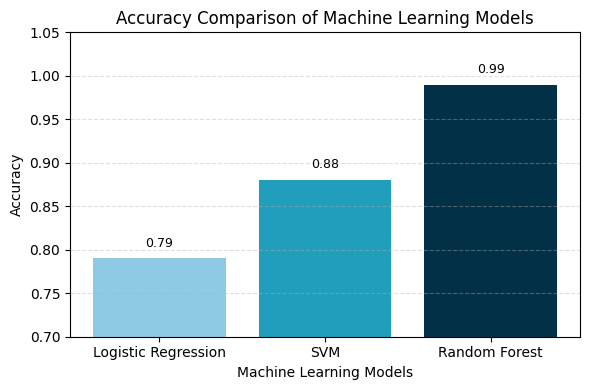

In [23]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracies = [0.79, 0.88, 0.99]  # your actual values

plt.figure(figsize=(6,4))

bars = plt.bar(
    models,
    accuracies,
    color=['#8ECae6', '#219ebc', '#023047']  # light → dark blue
)

# Add accuracy labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(0.7, 1.05)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Machine Learning Models")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()




In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



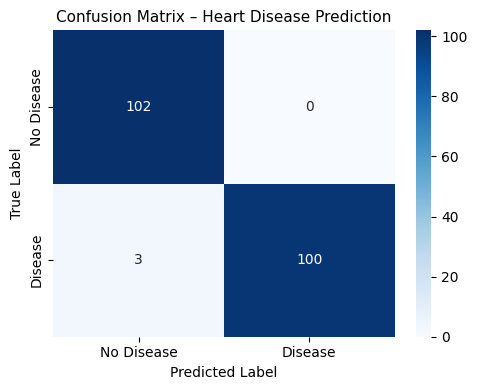

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title('Confusion Matrix – Heart Disease Prediction', fontsize=11)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()


In [26]:
X = df.drop('target', axis=1)
y = df['target']


In [27]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance', 
    ascending=False
)

feature_importance


,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


C:\Users\Salman Khalid\AppData\Local\Temp\ipykernel_22440\2410664885.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




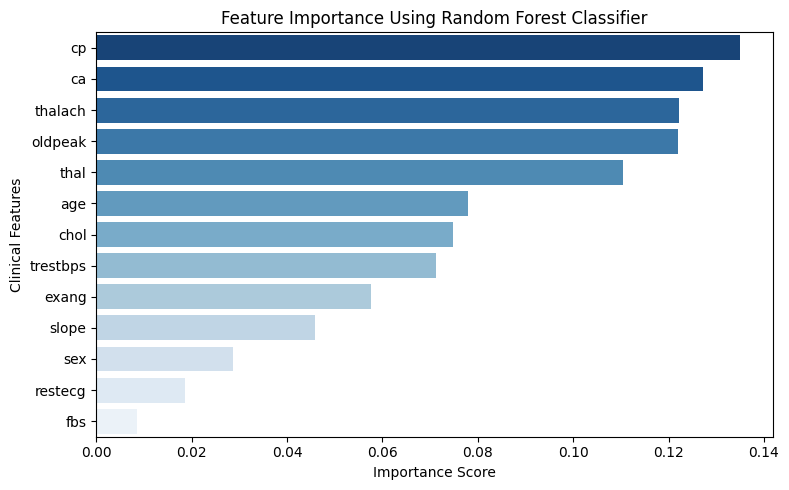

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette='Blues_r'
)

plt.title('Feature Importance Using Random Forest Classifier', fontsize=12)
plt.xlabel('Importance Score', fontsize=10)
plt.ylabel('Clinical Features', fontsize=10)

plt.tight_layout()
plt.show()


In [29]:
import pickle

# Save the Random Forest model you trained
with open("heart_disease_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully!")


Model saved successfully!
